In [37]:
# Gradient Descent for Linear Regression - Comprehensive Study Notebook
# Execute this cell to set up the notebook environment

!pip install numpy matplotlib ipywidgets -q

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import ipywidgets as widgets
from IPython.display import display, clear_output
import time

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12




# Gradient Descent for Linear Regression

## 1. Executive Summary

This notebook introduces **gradient descent**, the fundamental optimization algorithm that powers linear regression and virtually all modern machine learning models, including deep neural networks. While we previously explored how to evaluate model quality using the cost function $J(w,b)$, we now need a systematic way to find the parameter values that minimize this cost. Gradient descent provides exactly that—an iterative algorithm that intelligently "walks downhill" on the cost surface to find the lowest point.

The lecture develops gradient descent through an intuitive analogy: imagine standing on a hillside (the cost surface) and wanting to reach the valley floor (the minimum). You look around, find the steepest downhill direction, take a small step, and repeat until you reach the bottom. This simple idea, when expressed mathematically through derivatives and learning rates, becomes a powerful optimization tool that scales to models with thousands of parameters.

**Learning objectives:**
- Understand the intuition behind gradient descent as walking downhill to minimize cost
- Implement the gradient descent algorithm with simultaneous parameter updates
- Grasp the role of the learning rate $\alpha$ and its impact on convergence
- Calculate the derivatives for linear regression's squared error cost function
- Visualize gradient descent in action on contour plots and 3D surfaces
- Recognize why linear regression's cost function is convex (bowl-shaped), guaranteeing a single global minimum

## 2. Key Concepts & Glossary

| Term | Definition |
|------|------------|
| **Gradient Descent** | An iterative optimization algorithm that finds parameter values minimizing a cost function by repeatedly taking steps in the direction of steepest descent |
| **Learning Rate ($\alpha$)** | A positive number (typically between 0 and 1) that controls the size of each step in gradient descent |
| **Derivative** | Measures the slope of a function at a point; tells us which direction is "uphill" (positive slope) or "downhill" (negative slope) |
| **Simultaneous Update** | Updating all parameters ($w$ and $b$) at the same time using their old values, ensuring the algorithm behaves correctly |
| **Convergence** | The point at which gradient descent has reached a minimum and parameters stop changing significantly |
| **Local Minimum** | A point where the cost function is lower than all nearby points, but not necessarily the lowest possible point overall |
| **Global Minimum** | The absolute lowest point of the cost function; for convex functions, this is the only minimum |
| **Convex Function** | A bowl-shaped function with no local minima other than the single global minimum (like a soup bowl) |
| **Batch Gradient Descent** | The version of gradient descent that uses ALL training examples to compute each step |
| **Derivative Term** | $\frac{\partial}{\partial w}J(w,b)$ and $\frac{\partial}{\partial b}J(w,b)$ - the mathematical expressions telling us the slope of the cost function with respect to each parameter |
| **Overshooting** | When the learning rate is too large, causing gradient descent to leap past the minimum and potentially diverge |
| **Tangent Line** | A straight line that touches a curve at a single point, whose slope equals the derivative at that point |

## 3. Important Data Points

### Key Formulas

| Formula | Description |
|---------|-------------|
| $f_{w,b}(x) = wx + b$ | Linear regression model |
| $J(w,b) = \frac{1}{2m}\sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})^2$ | Squared error cost function |
| $w = w - \alpha \frac{\partial}{\partial w} J(w,b)$ | Gradient descent update for parameter $w$ |
| $b = b - \alpha \frac{\partial}{\partial b} J(w,b)$ | Gradient descent update for parameter $b$ |
| $\frac{\partial}{\partial w} J(w,b) = \frac{1}{m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)}) x^{(i)}$ | Derivative of cost with respect to $w$ |
| $\frac{\partial}{\partial b} J(w,b) = \frac{1}{m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})$ | Derivative of cost with respect to $b$ |

### Key Parameters and Their Effects

| Parameter | Too Small | Too Large | Just Right |
|-----------|-----------|-----------|------------|
| **Learning Rate ($\alpha$)** | Very slow convergence; takes many iterations | May overshoot minimum; can diverge completely | Steady progress to minimum |
| **Derivative Value** | Near minimum, steps get automatically smaller | Large steps when far from minimum | Steps adapt as we approach minimum |

### Important Properties of Linear Regression's Cost Function

| Property | Implication |
|----------|-------------|
| **Convex** | Bowl-shaped with a single global minimum |
| **No Local Minima** | Gradient descent always finds the best parameters |
| **Derivatives Have Closed Form** | We can compute exact update formulas |

## 4. Core Concepts

### 4.1 The Gradient Descent Intuition: Walking Downhill

Imagine yourself standing on a hillside (the cost function surface) with the goal of reaching the valley floor (the minimum). You're blindfolded but can feel the ground beneath your feet. How would you find your way down?

**The algorithm:**
1. **Feel around you** - Determine which direction slopes downward most steeply
2. **Take a small step** in that direction
3. **Repeat** until you can't go any further down

This is exactly what gradient descent does mathematically. The "steepest direction" is given by the **derivative** (slope) of the cost function at your current position. The "small step" size is controlled by the **learning rate** $\alpha$.


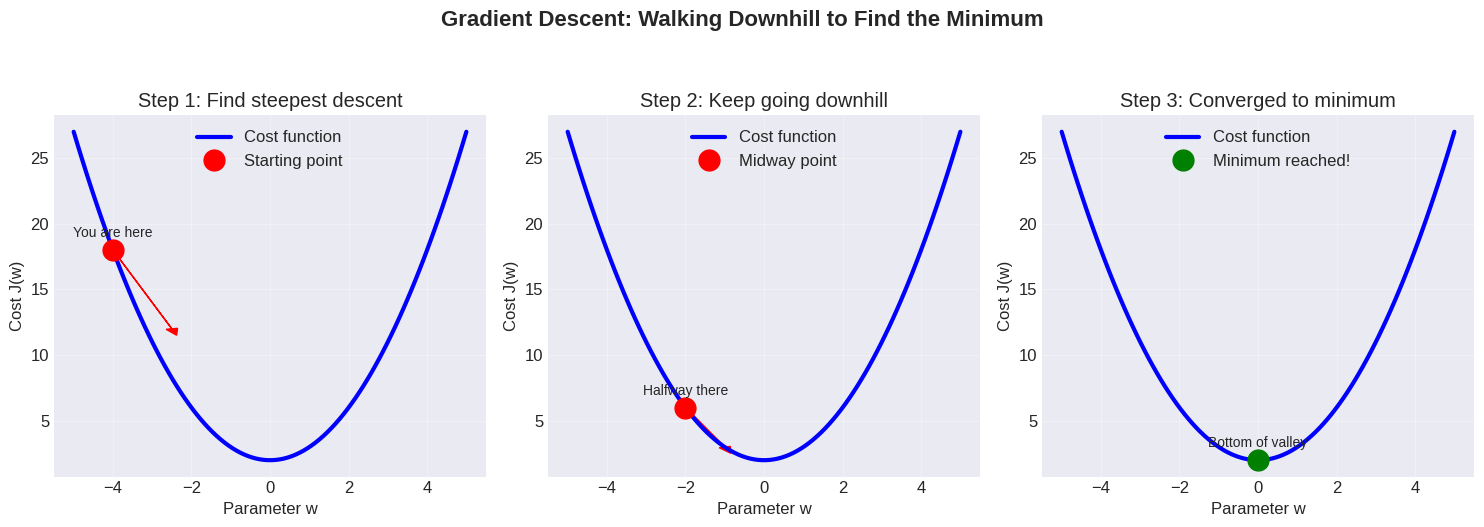

In [26]:
# Visualizing the "walking downhill" analogy
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Create a simple quadratic function (like a valley)
x = np.linspace(-5, 5, 100)
y = x**2 + 2  # Simple parabolic valley

# Point 1: Starting high on the left
axes[0].plot(x, y, 'b-', linewidth=3, label='Cost function')
axes[0].plot(-4, (-4)**2 + 2, 'ro', markersize=15, label='Starting point')
axes[0].annotate('You are here', xy=(-4, (-4)**2 + 2 + 1), ha='center', fontsize=10)
axes[0].arrow(-4, (-4)**2 + 2, 1.5, -6, head_width=0.3, head_length=0.5, fc='red', ec='red')
axes[0].set_xlabel('Parameter w')
axes[0].set_ylabel('Cost J(w)')
axes[0].set_title('Step 1: Find steepest descent')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Point 2: Midway down
axes[1].plot(x, y, 'b-', linewidth=3, label='Cost function')
axes[1].plot(-2, (-2)**2 + 2, 'ro', markersize=15, label='Midway point')
axes[1].annotate('Halfway there', xy=(-2, (-2)**2 + 2 + 1), ha='center', fontsize=10)
axes[1].arrow(-2, (-2)**2 + 2, 1, -3, head_width=0.3, head_length=0.5, fc='red', ec='red')
axes[1].set_xlabel('Parameter w')
axes[1].set_ylabel('Cost J(w)')
axes[1].set_title('Step 2: Keep going downhill')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Point 3: At the bottom
axes[2].plot(x, y, 'b-', linewidth=3, label='Cost function')
axes[2].plot(0, 2, 'go', markersize=15, label='Minimum reached!')
axes[2].annotate('Bottom of valley', xy=(0, 2 + 1), ha='center', fontsize=10)
axes[2].set_xlabel('Parameter w')
axes[2].set_ylabel('Cost J(w)')
axes[2].set_title('Step 3: Converged to minimum')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.suptitle('Gradient Descent: Walking Downhill to Find the Minimum', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()


### 4.2 The Gradient Descent Algorithm

The gradient descent algorithm is remarkably simple. For each parameter, we repeatedly apply an update rule that moves the parameter in the direction that reduces cost:

**For parameter $w$:** $w = w - \alpha \frac{\partial}{\partial w} J(w,b)$

**For parameter $b$:** $b = b - \alpha \frac{\partial}{\partial b} J(w,b)$

**Critical Rule: Simultaneous Update**
Both parameters must be updated using their **old values**. This means:
1. Compute the right-hand side for $w$ using current $w$ and $b$ (store in temporary variable)
2. Compute the right-hand side for $b$ using current $w$ and $b$ (store in temporary variable)
3. Update $w$ and $b$ simultaneously with the stored values


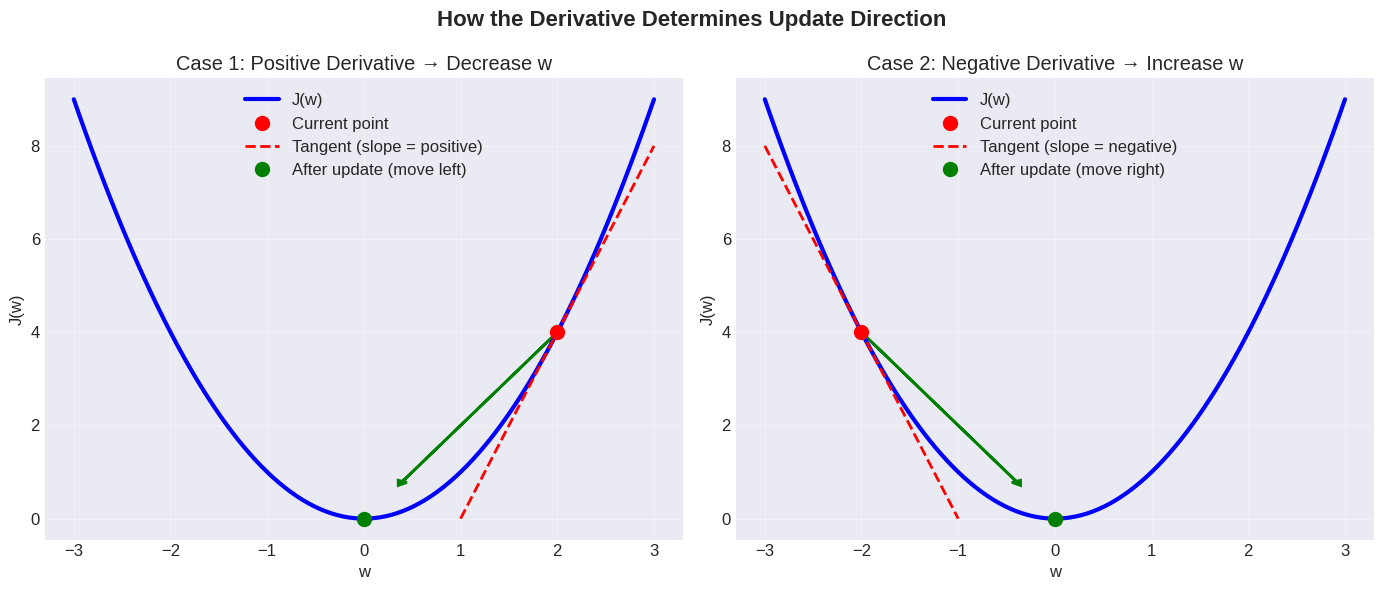

🔑 Key Insight: The update rule $w = w - \alpha \frac{\partial}{\partial w}J(w,b)$ automatically:
   • Moves LEFT when derivative is POSITIVE (subtract positive number)
   • Moves RIGHT when derivative is NEGATIVE (subtract negative number = add)
   • Always moves toward the minimum, regardless of starting point!


In [27]:
# Visualizing the gradient descent update rule
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Create a quadratic function
x = np.linspace(-3, 3, 100)
y = x**2

# Point on the right side (positive slope)
start_x = 2
start_y = start_x**2
slope = 2 * start_x  # derivative of x^2 is 2x

# Plot the function
axes[0].plot(x, y, 'b-', linewidth=3, label='J(w)')
axes[0].plot(start_x, start_y, 'ro', markersize=10, label='Current point')

# Draw tangent line
tangent_x = np.linspace(start_x - 1, start_x + 1, 10)
tangent_y = start_y + slope * (tangent_x - start_x)
axes[0].plot(tangent_x, tangent_y, 'r--', linewidth=2, label='Tangent (slope = positive)')

# Show update direction
new_x = start_x - 0.5 * slope  # alpha = 0.5
new_y = new_x**2
axes[0].arrow(start_x, start_y, (new_x - start_x) * 0.8, (new_y - start_y) * 0.8,
             head_width=0.1, head_length=0.1, fc='green', ec='green', linewidth=2)
axes[0].plot(new_x, new_y, 'go', markersize=10, label='After update (move left)')

axes[0].set_xlabel('w')
axes[0].set_ylabel('J(w)')
axes[0].set_title('Case 1: Positive Derivative → Decrease w')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Point on the left side (negative slope)
start_x = -2
start_y = start_x**2
slope = 2 * start_x  # negative

# Plot the function
axes[1].plot(x, y, 'b-', linewidth=3, label='J(w)')
axes[1].plot(start_x, start_y, 'ro', markersize=10, label='Current point')

# Draw tangent line
tangent_x = np.linspace(start_x - 1, start_x + 1, 10)
tangent_y = start_y + slope * (tangent_x - start_x)
axes[1].plot(tangent_x, tangent_y, 'r--', linewidth=2, label='Tangent (slope = negative)')

# Show update direction
new_x = start_x - 0.5 * slope  # subtracting negative = adding positive
new_y = new_x**2
axes[1].arrow(start_x, start_y, (new_x - start_x) * 0.8, (new_y - start_y) * 0.8,
             head_width=0.1, head_length=0.1, fc='green', ec='green', linewidth=2)
axes[1].plot(new_x, new_y, 'go', markersize=10, label='After update (move right)')

axes[1].set_xlabel('w')
axes[1].set_ylabel('J(w)')
axes[1].set_title('Case 2: Negative Derivative → Increase w')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('How the Derivative Determines Update Direction', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("🔑 Key Insight: The update rule $w = w - \\alpha \\frac{\\partial}{\\partial w}J(w,b)$ automatically:")
print("   • Moves LEFT when derivative is POSITIVE (subtract positive number)")
print("   • Moves RIGHT when derivative is NEGATIVE (subtract negative number = add)")
print("   • Always moves toward the minimum, regardless of starting point!")

### 4.3 The Learning Rate: Finding the Right Step Size

The learning rate $\alpha$ is perhaps the most important hyperparameter in gradient descent. It determines how big a step we take in the direction of steepest descent.

**If $\alpha$ is too small:** Gradient descent works but is painfully slow. Like taking tiny baby steps when you could be walking normally, you'll eventually reach the minimum but it might take thousands of iterations.

**If $\alpha$ is too large:** Gradient descent may overshoot the minimum, fail to converge, or even diverge (cost increases with each step). This is like trying to run down a steep hill—you might lose control and end up far from where you intended.

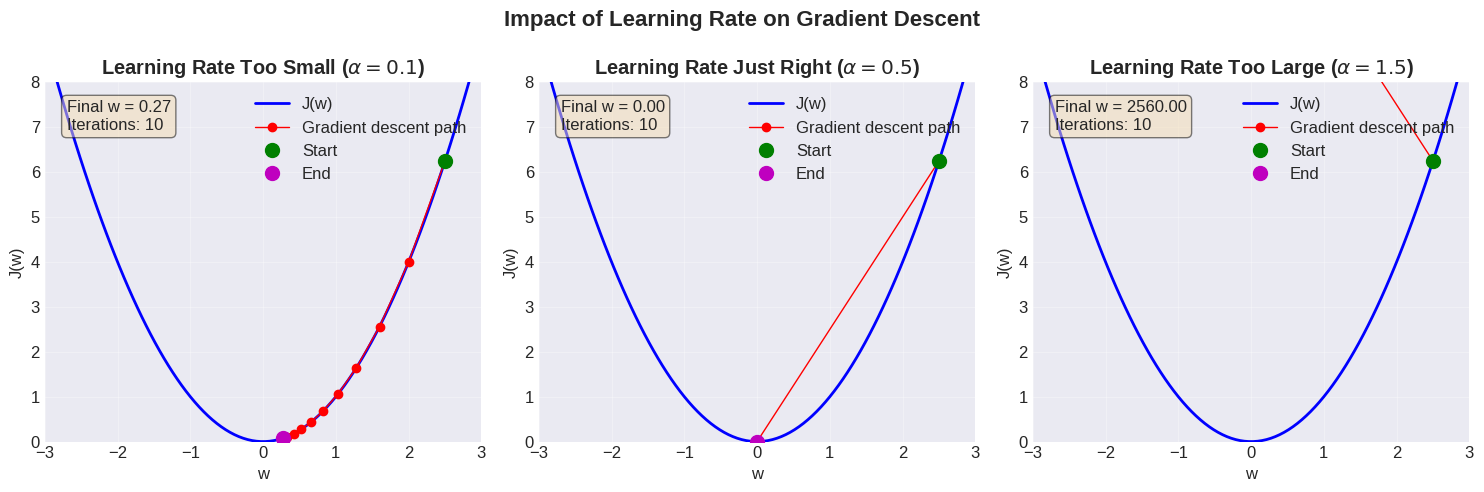

📊 Observations:
   • $\alpha = 0.1$:  Slow progress, hasn't reached minimum after 10 steps
   • $\alpha = 0.5$:  Fast, stable convergence to minimum
   • $\alpha = 1.5$:  Overshoots and oscillates, fails to converge


In [28]:
# Visualizing the effects of different learning rates
def quadratic(x):
    return x**2

def gradient(x):
    return 2*x

# Starting point
w_start = 2.5
iterations = 10

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
alphas = [0.1, 0.5, 1.5]
titles = ['Learning Rate Too Small ($\\alpha=0.1$)',
          'Learning Rate Just Right ($\\alpha=0.5$)',
          'Learning Rate Too Large ($\\alpha=1.5$)']

for idx, (alpha, title) in enumerate(zip(alphas, titles)):
    # Run gradient descent
    w = w_start
    w_history = [w]
    J_history = [quadratic(w)]

    for i in range(iterations):
        w = w - alpha * gradient(w)
        w_history.append(w)
        J_history.append(quadratic(w))

    # Plot the function
    x_plot = np.linspace(-3, 3, 100)
    y_plot = quadratic(x_plot)

    axes[idx].plot(x_plot, y_plot, 'b-', linewidth=2, label='J(w)')
    axes[idx].plot(w_history, J_history, 'ro-', markersize=6, linewidth=1, label='Gradient descent path')
    axes[idx].plot(w_history[0], J_history[0], 'go', markersize=10, label='Start')
    axes[idx].plot(w_history[-1], J_history[-1], 'mo', markersize=10, label='End')

    axes[idx].set_xlabel('w')
    axes[idx].set_ylabel('J(w)')
    axes[idx].set_title(title, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc='upper right')
    axes[idx].set_xlim(-3, 3)
    axes[idx].set_ylim(0, 8)

    # Add text showing final position
    axes[idx].text(0.05, 0.95, f'Final w = {w_history[-1]:.2f}\nIterations: {iterations}',
                  transform=axes[idx].transAxes, verticalalignment='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Impact of Learning Rate on Gradient Descent', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("📊 Observations:")
print("   • $\\alpha = 0.1$:  Slow progress, hasn't reached minimum after 10 steps")
print("   • $\\alpha = 0.5$:  Fast, stable convergence to minimum")
print("   • $\\alpha = 1.5$:  Overshoots and oscillates, fails to converge")

### 4.4 Local Minima and Convex Functions

For some cost functions (like those in neural networks), there can be multiple "valleys" or **local minima**. Where you end up depends on where you start—like hiking in a mountain range with multiple valleys.

However, **linear regression's squared error cost function is special**: it's **convex**, meaning it has the shape of a bowl with exactly one minimum—the **global minimum**. This is why gradient descent always finds the best possible parameters for linear regression, regardless of where you start.

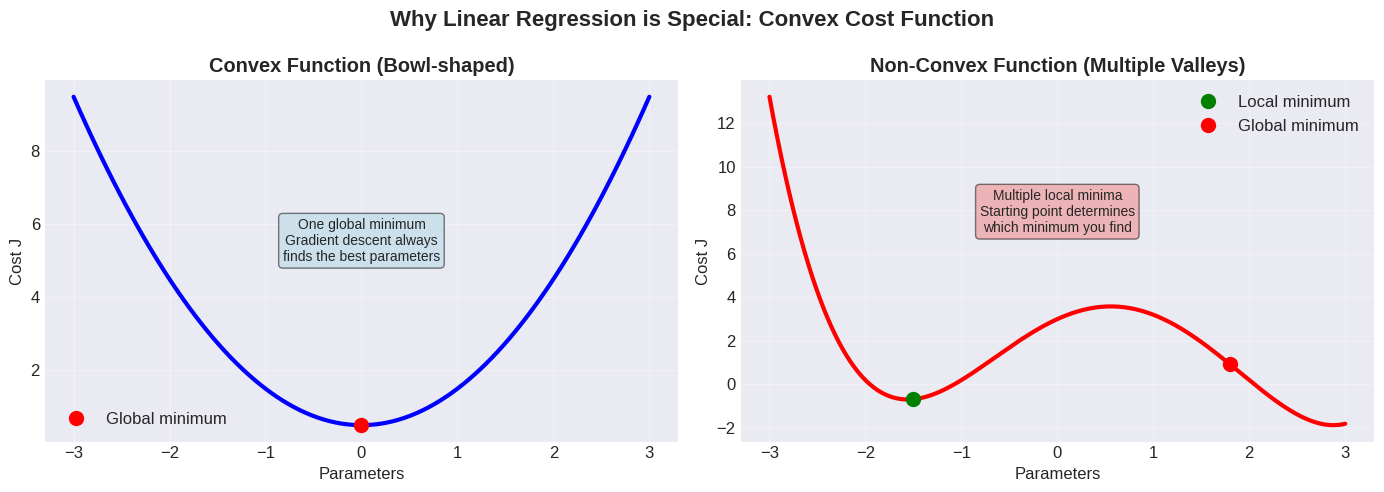

In [29]:
# Visualizing convex vs. non-convex functions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Convex function (like linear regression cost)
x = np.linspace(-3, 3, 100)
convex = x**2 + 0.5

axes[0].plot(x, convex, 'b-', linewidth=3)
axes[0].plot(0, 0.5, 'ro', markersize=10, label='Global minimum')
axes[0].set_xlabel('Parameters')
axes[0].set_ylabel('Cost J')
axes[0].set_title('Convex Function (Bowl-shaped)', fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()
axes[0].text(0, 5, 'One global minimum\nGradient descent always\nfinds the best parameters',
            ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# Non-convex function (like neural network cost)
x = np.linspace(-3, 3, 300)
nonconvex = 0.2*x**4 - 0.5*x**3 - 1.5*x**2 + 2*x + 3

axes[1].plot(x, nonconvex, 'r-', linewidth=3)
axes[1].plot(-1.5, nonconvex[np.argmin(np.abs(x - (-1.5)))], 'go', markersize=10, label='Local minimum')
axes[1].plot(1.8, nonconvex[np.argmin(np.abs(x - 1.8))], 'ro', markersize=10, label='Global minimum')
axes[1].set_xlabel('Parameters')
axes[1].set_ylabel('Cost J')
axes[1].set_title('Non-Convex Function (Multiple Valleys)', fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].text(0, 7, 'Multiple local minima\nStarting point determines\nwhich minimum you find',
            ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='lightcoral', alpha=0.5))

plt.suptitle('Why Linear Regression is Special: Convex Cost Function', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


### 4.5 Derivatives for Linear Regression

For linear regression with the squared error cost function, the derivatives have elegant closed forms:

$$\frac{\partial}{\partial w} J(w,b) = \frac{1}{m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)}) x^{(i)}$$

$$\frac{\partial}{\partial b} J(w,b) = \frac{1}{m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})$$

Where $f_{w,b}(x^{(i)}) = wx^{(i)} + b$

Notice the beautiful pattern:
- For $w$, we multiply each error by its corresponding input feature $x^{(i)}$
- For $b$, we simply sum the errors (no multiplication)

The $\frac{1}{2}$ in the original cost function was strategically placed so that when we take derivatives, the $2$ cancels out, leaving these clean expressions.

## 5. Visualizations (CRITICAL)

### 5.1 Complete Gradient Descent Visualization with Contour Plot



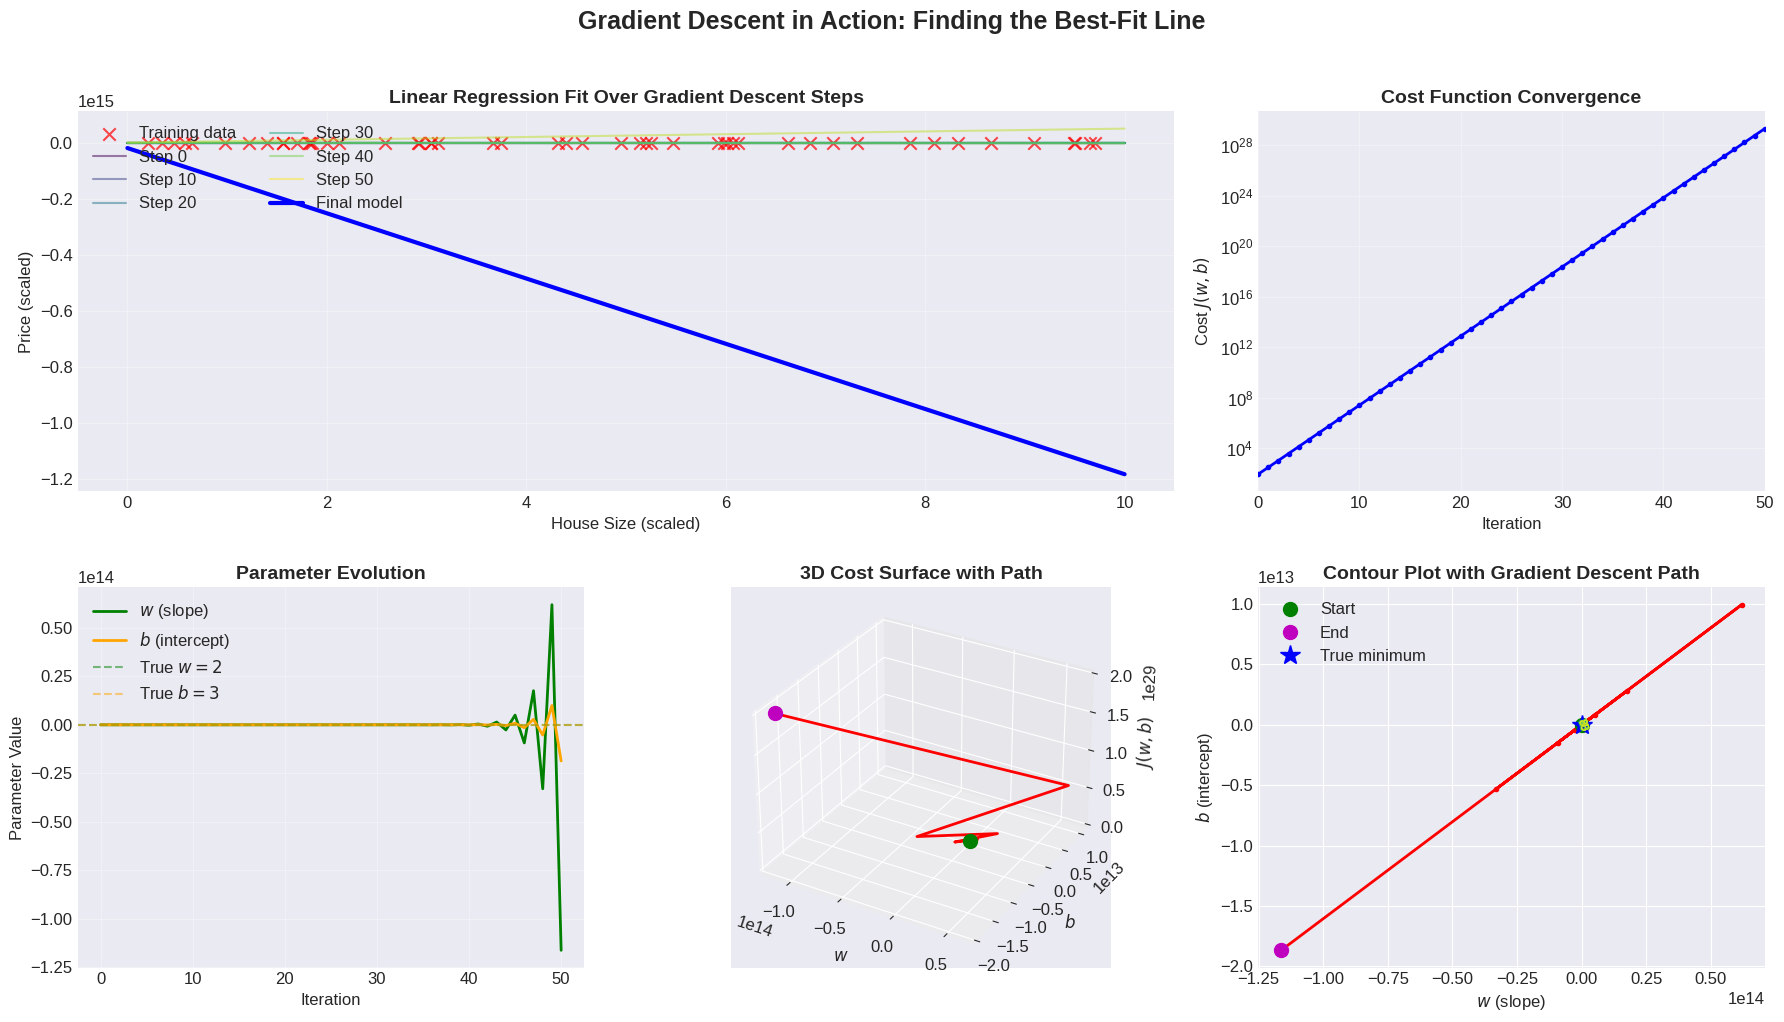

✅ Gradient descent completed!
   Initial parameters: $w = 0$, $b = 0$
   Final parameters:   $w = -116303972981894.8438$, $b = -18669707253738.8789$
   True parameters:    $w = 2.0$, $b = 3.0$
   Initial cost: $87.7116$
   Final cost:   $199657316411306368061361094656.0000$


In [30]:
# Create synthetic data for linear regression
np.random.seed(42)
m = 50
X = np.random.rand(m, 1) * 10  # House sizes 0-10 (scaled for simplicity)
y = 2 * X + 3 + np.random.randn(m, 1) * 1.5  # True line: y = 2x + 3 with noise
X = X.flatten()
y = y.flatten()

# Gradient descent implementation
def compute_cost(X, y, w, b):
    m = len(X)
    predictions = w * X + b
    cost = (1/(2*m)) * np.sum((predictions - y)**2)
    return cost

def compute_gradient(X, y, w, b):
    m = len(X)
    predictions = w * X + b
    dw = (1/m) * np.sum((predictions - y) * X)
    db = (1/m) * np.sum(predictions - y)
    return dw, db

def gradient_descent(X, y, w_init, b_init, alpha, num_iters):
    w = w_init
    b = b_init
    w_history = [w]
    b_history = [b]
    J_history = [compute_cost(X, y, w, b)]

    for i in range(num_iters):
        dw, db = compute_gradient(X, y, w, b)
        w = w - alpha * dw
        b = b - alpha * db

        w_history.append(w)
        b_history.append(b)
        J_history.append(compute_cost(X, y, w, b))

    return w, b, w_history, b_history, J_history

# Run gradient descent
w_init, b_init = 0, 0
alpha = 0.1
num_iters = 50
w_final, b_final, w_hist, b_hist, J_hist = gradient_descent(X, y, w_init, b_init, alpha, num_iters)

# Create the visualization
fig = plt.figure(figsize=(18, 10))

# Plot 1: Data and regression line evolution
ax1 = fig.add_subplot(2, 3, (1, 2))
ax1.scatter(X, y, color='red', marker='x', s=80, label='Training data', alpha=0.7)

# Plot lines at different stages
x_line = np.linspace(0, 10, 100)
# Calculate the step for sampling history
history_step = max(1, len(w_hist) // 10)
# Generate a sequence of indices for history points to plot
sampled_indices = list(range(0, len(w_hist), history_step))
# Determine the number of colors needed based on the sampled_indices
num_colors = len(sampled_indices)
colors = plt.cm.viridis(np.linspace(0, 1, num_colors))

# Iterate through the sampled indices and their corresponding color index
for k, i in enumerate(sampled_indices):
    y_line = w_hist[i] * x_line + b_hist[i]
    ax1.plot(x_line, y_line, color=colors[k],
             linewidth=1.5, alpha=0.5, label=f'Step {i}' if i % 10 == 0 else '')

# Final line
y_final = w_final * x_line + b_final
ax1.plot(x_line, y_final, 'b-', linewidth=3, label='Final model')

ax1.set_xlabel('House Size (scaled)', fontsize=12)
ax1.set_ylabel('Price (scaled)', fontsize=12)
ax1.set_title('Linear Regression Fit Over Gradient Descent Steps', fontweight='bold', fontsize=14)
ax1.grid(True, alpha=0.3)
ax1.legend(loc='upper left', ncol=2)

# Plot 2: Cost history
ax2 = fig.add_subplot(2, 3, 3)
ax2.plot(range(len(J_hist)), J_hist, 'b-', linewidth=2, marker='o', markersize=3)
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Cost $J(w,b)$', fontsize=12)
ax2.set_title('Cost Function Convergence', fontweight='bold', fontsize=14)
ax2.grid(True, alpha=0.3)
ax2.set_yscale('log')
ax2.set_xlim(0, len(J_hist)-1)

# Plot 3: Parameter evolution
ax3 = fig.add_subplot(2, 3, 4)
ax3.plot(range(len(w_hist)), w_hist, 'g-', linewidth=2, label='$w$ (slope)')
ax3.plot(range(len(b_hist)), b_hist, 'orange', linewidth=2, label='$b$ (intercept)')
ax3.axhline(y=2, color='g', linestyle='--', alpha=0.5, label='True $w=2$')
ax3.axhline(y=3, color='orange', linestyle='--', alpha=0.5, label='True $b=3$')
ax3.set_xlabel('Iteration', fontsize=12)
ax3.set_ylabel('Parameter Value', fontsize=12)
ax3.set_title('Parameter Evolution', fontweight='bold', fontsize=14)
ax3.grid(True, alpha=0.3)
ax3.legend()

# Plot 4: Contour plot with path
ax4 = fig.add_subplot(2, 3, 5, projection='3d')

# Create meshgrid for contour
w_range = np.linspace(0, 4, 50)
b_range = np.linspace(0, 6, 50)
W, B = np.meshgrid(w_range, b_range)
Z = np.zeros_like(W)

for i in range(len(w_range)):
    for j in range(len(b_range)):
        Z[j, i] = compute_cost(X, y, W[j, i], B[j, i])

# Plot surface
surf = ax4.plot_surface(W, B, Z, cmap='viridis', alpha=0.7, linewidth=0, antialiased=True)
ax4.contour(W, B, Z, zdir='z', offset=Z.min(), cmap='viridis', alpha=0.5)
ax4.plot(w_hist, b_hist, J_hist, 'r-', linewidth=2, label='Gradient descent path')
ax4.plot(w_hist[0], b_hist[0], J_hist[0], 'go', markersize=10, label='Start')
ax4.plot(w_hist[-1], b_hist[-1], J_hist[-1], 'mo', markersize=10, label='End')

ax4.set_xlabel('$w$')
ax4.set_ylabel('$b$')
ax4.set_zlabel('$J(w,b)$')
ax4.set_title('3D Cost Surface with Path', fontweight='bold', fontsize=14)

# Plot 5: 2D contour with path
ax5 = fig.add_subplot(2, 3, 6)
contour = ax5.contour(W, B, Z, levels=20, cmap='viridis')
ax5.clabel(contour, inline=True, fontsize=8)
ax5.plot(w_hist, b_hist, 'r-', linewidth=2, marker='o', markersize=3)
ax5.plot(w_hist[0], b_hist[0], 'go', markersize=10, label='Start')
ax5.plot(w_hist[-1], b_hist[-1], 'mo', markersize=10, label='End')
ax5.plot(2, 3, 'b*', markersize=15, label='True minimum')
ax5.set_xlabel('$w$ (slope)', fontsize=12)
ax5.set_ylabel('$b$ (intercept)', fontsize=12)
ax5.set_title('Contour Plot with Gradient Descent Path', fontweight='bold', fontsize=14)
ax5.legend()

plt.suptitle('Gradient Descent in Action: Finding the Best-Fit Line', fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"✅ Gradient descent completed!")
print(f"   Initial parameters: $w = {w_init}$, $b = {b_init}$")
print(f"   Final parameters:   $w = {w_final:.4f}$, $b = {b_final:.4f}$")
print(f"   True parameters:    $w = 2.0$, $b = 3.0$")
print(f"   Initial cost: ${J_hist[0]:.4f}$")
print(f"   Final cost:   ${J_hist[-1]:.4f}$")

### 5.2 Interactive Learning Rate Explorer


In [ ]:
# Interactive widget to explore learning rate effects
def explore_learning_rate(alpha=0.1):
    # Run gradient descent with selected alpha
    w_init, b_init = 0, 0
    num_iters = 30
    w_final, b_final, w_hist, b_hist, J_hist = gradient_descent(X, y, w_init, b_init, alpha, num_iters)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Plot 1: Cost convergence
    axes[0].plot(range(len(J_hist)), J_hist, 'b-', linewidth=2, marker='o', markersize=3)
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Cost $J(w,b)$')
    axes[0].set_title(f'Cost Convergence ($\\alpha={alpha}$)')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_yscale('log')

    # Plot 2: Parameter evolution
    axes[1].plot(range(len(w_hist)), w_hist, 'g-', label='$w$')
    axes[1].plot(range(len(b_hist)), b_hist, 'orange', label='$b$')
    axes[1].axhline(y=2, color='g', linestyle='--', alpha=0.5)
    axes[1].axhline(y=3, color='orange', linestyle='--', alpha=0.5)
    axes[1].set_xlabel('Iteration')
    axes[1].set_ylabel('Parameter Value')
    axes[1].set_title('Parameter Evolution')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    # Plot 3: Final fit
    axes[2].scatter(X, y, color='red', marker='x', s=50, alpha=0.6)
    x_line = np.linspace(0, 10, 100)
    y_line = w_final * x_line + b_final
    axes[2].plot(x_line, y_line, 'b-', linewidth=2)
    axes[2].set_xlabel('X')
    axes[2].set_ylabel('y')
    axes[2].set_title(f'Final Model: $y = {w_final:.2f}x + {b_final:.2f}$')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # Convergence check
    if J_hist[-1] < J_hist[0]:
        if J_hist[-1] < 1.0:
            print(f"✅ Good convergence! Final cost: {J_hist[-1]:.4f}")
        else:
            print(f"⚠️  Converging slowly. Final cost: {J_hist[-1]:.4f}")
    else:
        print(f"❌ Diverging! Cost increased. Try a smaller learning rate.")

# Create interactive slider
print("🎮 Interactive Learning Rate Explorer")
print("Move the slider to see how different learning rates affect convergence")
alpha_slider = widgets.FloatSlider(value=0.1, min=0.01, max=1.0, step=0.01, description='$\\alpha$:')
widgets.interact(explore_learning_rate, alpha=alpha_slider)


### 5.3 Batch Gradient Descent Visualization

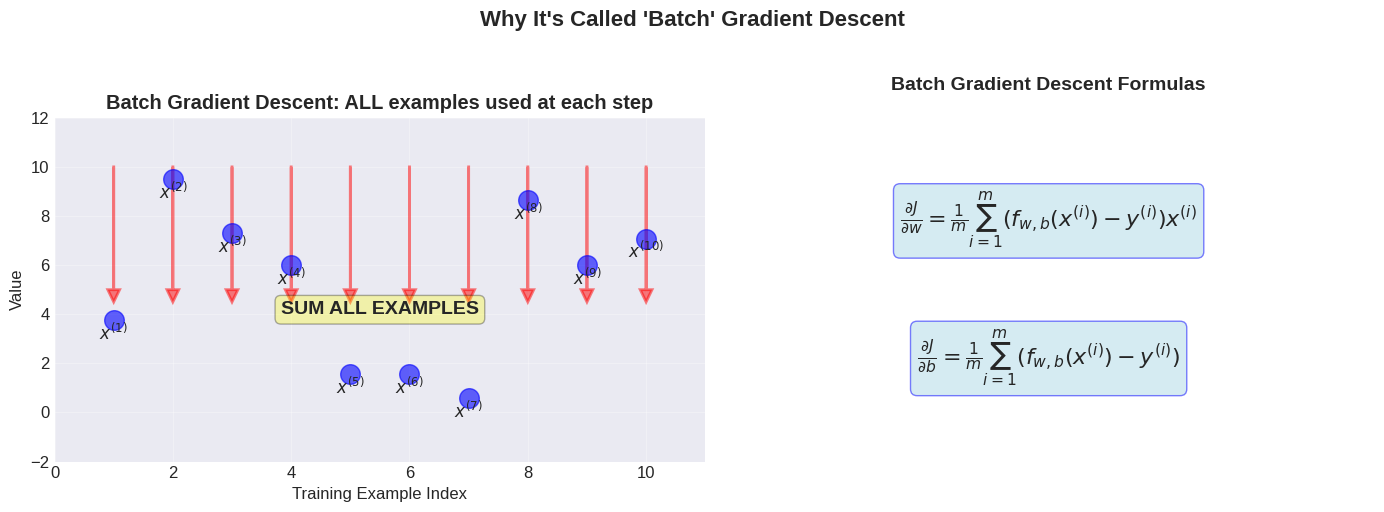

📌 Key Point: 'Batch' means we use ALL training examples to compute each gradient step.
   This gives a stable, accurate estimate of the true gradient direction.


In [32]:
# Visualizing the "batch" nature of gradient descent
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Illustration of batch processing
# Fixed: Generate random points once and reuse for consistent positioning
np.random.seed(42)  # For reproducibility
y_positions = np.random.rand(10) * 10
axes[0].scatter(range(1, 11), y_positions, s=200, alpha=0.6, color='blue', zorder=5)

for i in range(1, 11):
    # Fixed: Use the same y_positions for text placement
    axes[0].text(i, y_positions[i-1] - 0.8, f'$x^{{({i})}}$', ha='center', fontsize=12, zorder=10)

axes[0].set_xlim(0, 11)
axes[0].set_ylim(-2, 12)
axes[0].set_xlabel('Training Example Index', fontsize=12)
axes[0].set_ylabel('Value', fontsize=12)
axes[0].set_title('Batch Gradient Descent: ALL examples used at each step', fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Add arrows showing summation - Fixed: Start arrows from consistent y position
for i in range(1, 11):
    axes[0].arrow(i, 10, 0, -5, head_width=0.2, head_length=0.5, fc='red', ec='red', alpha=0.5, linewidth=2)

axes[0].text(5.5, 4, 'SUM ALL EXAMPLES', ha='center', fontsize=14, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3, edgecolor='black'))

# Plot 2: Update formula visualization - Fixed: Proper LaTeX formatting
formula_text1 = r'$\frac{\partial J}{\partial w} = \frac{1}{m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)}) x^{(i)}$'
formula_text2 = r'$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})$'

# Fixed: Use separate text elements for better positioning
axes[1].text(0.5, 0.7, formula_text1, fontsize=16, ha='center', va='center',
            transform=axes[1].transAxes, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5, edgecolor='blue'))
axes[1].text(0.5, 0.3, formula_text2, fontsize=16, ha='center', va='center',
            transform=axes[1].transAxes, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5, edgecolor='blue'))

axes[1].axis('off')
axes[1].set_title('Batch Gradient Descent Formulas', fontweight='bold', fontsize=14, pad=20)

plt.suptitle("Why It's Called 'Batch' Gradient Descent", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("📌 Key Point: 'Batch' means we use ALL training examples to compute each gradient step.")
print("   This gives a stable, accurate estimate of the true gradient direction.")


## 6. Code Examples

### 6.1 Complete Linear Regression with Gradient Descent Implementation


🚀 Training Linear Regression with Gradient Descent
Iteration 0: Cost = 87.711647, w = 0.0692, b = 0.0119
Iteration 100: Cost = 2.222733, w = 2.2705, b = 0.4445
Iteration 200: Cost = 1.916412, w = 2.3779, b = 0.5388
Iteration 300: Cost = 1.860999, w = 2.3726, b = 0.6128
Iteration 400: Cost = 1.809327, w = 2.3615, b = 0.6839

📊 Final Results:
   $w$ (slope): 2.3506
   $b$ (intercept): 0.7521
   Final cost: 1.7610
   $R^2$ score: 0.8948


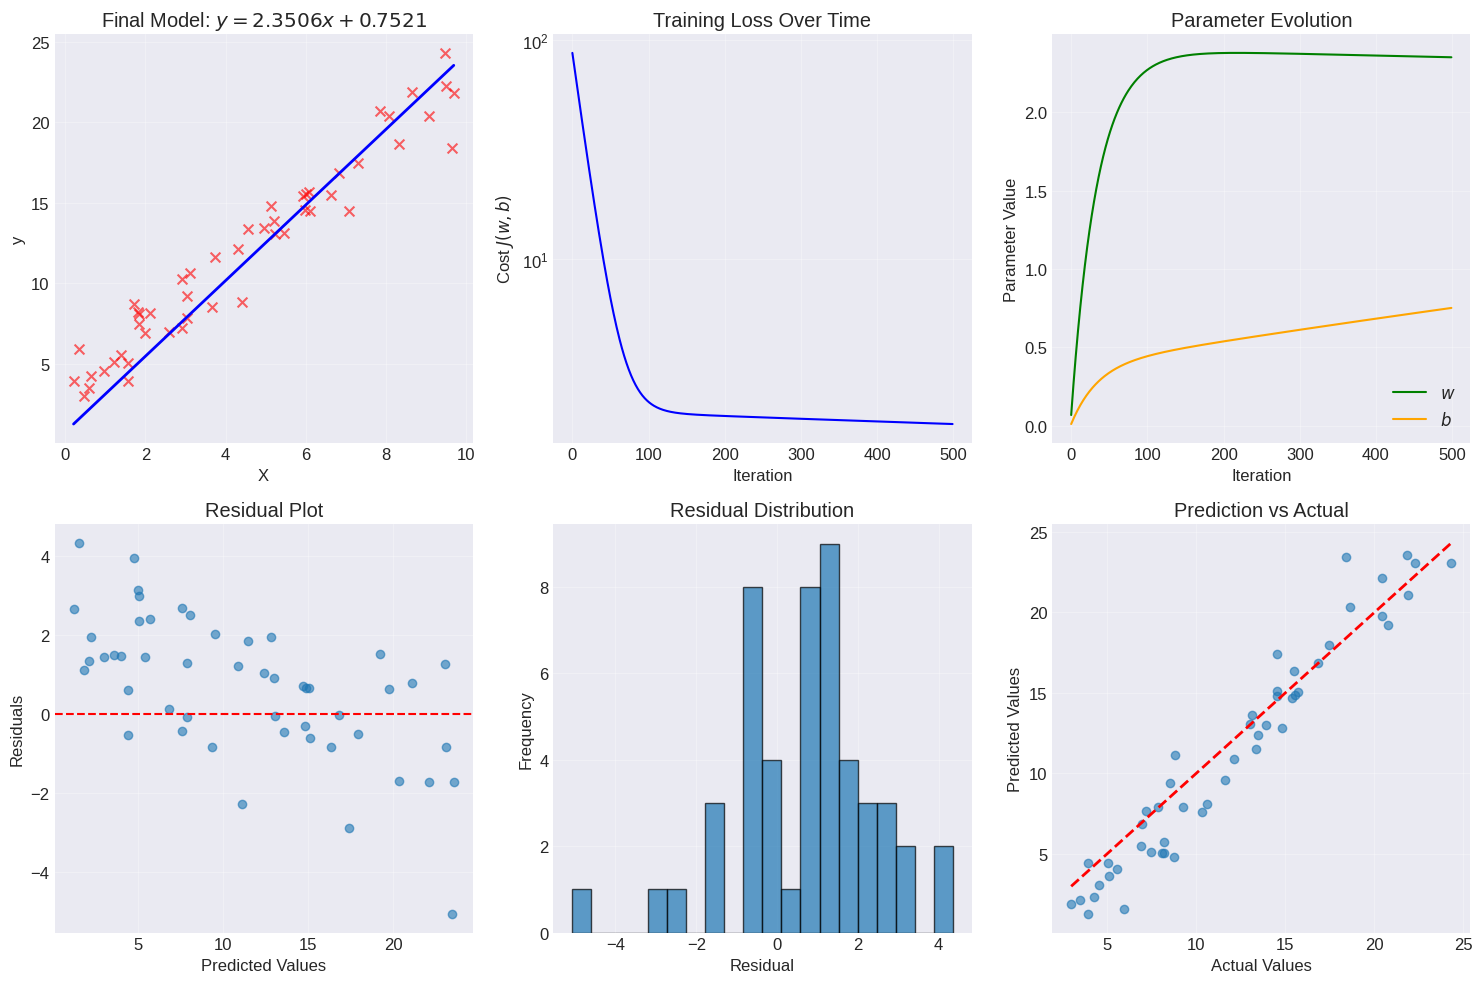


🏠 Predictions for new houses:
   Size 2.0 → Predicted price 5.45
   Size 5.0 → Predicted price 12.51
   Size 8.0 → Predicted price 19.56


In [33]:
class LinearRegressionGD:
    """
    Linear Regression implemented with Gradient Descent from scratch
    """

    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.w = None
        self.b = None
        self.loss_history = []
        self.w_history = []
        self.b_history = []

    def fit(self, X, y):
        """
        Fit the linear regression model using gradient descent

        Args:
            X: array of shape (m,) or (m,1) - input features
            y: array of shape (m,) - target values
        """
        # Ensure X is 1D
        if len(X.shape) > 1:
            X = X.flatten()

        m = len(X)

        # Initialize parameters
        self.w = 0
        self.b = 0

        # Gradient descent loop
        for i in range(self.n_iterations):
            # Make predictions
            y_pred = self.w * X + self.b

            # Calculate cost
            cost = (1/(2*m)) * np.sum((y_pred - y)**2)
            self.loss_history.append(cost)

            # Calculate gradients
            dw = (1/m) * np.sum((y_pred - y) * X)
            db = (1/m) * np.sum(y_pred - y)

            # Update parameters (simultaneous update)
            self.w = self.w - self.learning_rate * dw
            self.b = self.b - self.learning_rate * db

            # Store history
            self.w_history.append(self.w)
            self.b_history.append(self.b)

            # Optional: print progress
            if i % 100 == 0:
                print(f"Iteration {i}: Cost = {cost:.6f}, w = {self.w:.4f}, b = {self.b:.4f}")

        return self

    def predict(self, X):
        """Make predictions for new input values"""
        if len(X.shape) > 1:
            X = X.flatten()
        return self.w * X + self.b

    def score(self, X, y):
        """Calculate $R^2$ score (coefficient of determination)"""
        y_pred = self.predict(X)
        ss_res = np.sum((y - y_pred)**2)
        ss_tot = np.sum((y - np.mean(y))**2)
        r2 = 1 - (ss_res / ss_tot)
        return r2

    def plot_training(self, X, y):
        """Plot the training progress"""
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))

        # Original data and final fit
        axes[0, 0].scatter(X, y, color='red', marker='x', s=50, alpha=0.6)
        x_line = np.linspace(X.min(), X.max(), 100)
        y_line = self.predict(x_line)
        axes[0, 0].plot(x_line, y_line, 'b-', linewidth=2)
        axes[0, 0].set_xlabel('X')
        axes[0, 0].set_ylabel('y')
        axes[0, 0].set_title(f'Final Model: $y = {self.w:.4f}x + {self.b:.4f}$')
        axes[0, 0].grid(True, alpha=0.3)

        # Loss history
        axes[0, 1].plot(range(len(self.loss_history)), self.loss_history, 'b-')
        axes[0, 1].set_xlabel('Iteration')
        axes[0, 1].set_ylabel('Cost $J(w,b)$')
        axes[0, 1].set_title('Training Loss Over Time')
        axes[0, 1].grid(True, alpha=0.3)
        axes[0, 1].set_yscale('log')

        # Parameter history
        axes[0, 2].plot(range(len(self.w_history)), self.w_history, 'g-', label='$w$')
        axes[0, 2].plot(range(len(self.b_history)), self.b_history, 'orange', label='$b$')
        axes[0, 2].set_xlabel('Iteration')
        axes[0, 2].set_ylabel('Parameter Value')
        axes[0, 2].set_title('Parameter Evolution')
        axes[0, 2].grid(True, alpha=0.3)
        axes[0, 2].legend()

        # Residual plot
        y_pred = self.predict(X)
        residuals = y - y_pred
        axes[1, 0].scatter(y_pred, residuals, alpha=0.6)
        axes[1, 0].axhline(y=0, color='r', linestyle='--')
        axes[1, 0].set_xlabel('Predicted Values')
        axes[1, 0].set_ylabel('Residuals')
        axes[1, 0].set_title('Residual Plot')
        axes[1, 0].grid(True, alpha=0.3)

        # Distribution of residuals
        axes[1, 1].hist(residuals, bins=20, edgecolor='black', alpha=0.7)
        axes[1, 1].set_xlabel('Residual')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].set_title('Residual Distribution')
        axes[1, 1].grid(True, alpha=0.3)

        # Prediction vs actual
        axes[1, 2].scatter(y, y_pred, alpha=0.6)
        axes[1, 2].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2)
        axes[1, 2].set_xlabel('Actual Values')
        axes[1, 2].set_ylabel('Predicted Values')
        axes[1, 2].set_title('Prediction vs Actual')
        axes[1, 2].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

# Demonstrate the class
print("🚀 Training Linear Regression with Gradient Descent")
print("=" * 50)

# Create and train model
model = LinearRegressionGD(learning_rate=0.001, n_iterations=500)
model.fit(X, y)

print("\n📊 Final Results:")
print(f"   $w$ (slope): {model.w:.4f}")
print(f"   $b$ (intercept): {model.b:.4f}")
print(f"   Final cost: {model.loss_history[-1]:.4f}")
print(f"   $R^2$ score: {model.score(X, y):.4f}")

# Visualize training
model.plot_training(X, y)

# Make predictions for new houses
new_houses = np.array([2, 5, 8])
predictions = model.predict(new_houses)
print("\n🏠 Predictions for new houses:")
for size, price in zip(new_houses, predictions):
    print(f"   Size {size:.1f} → Predicted price {price:.2f}")

### 6.2 Comparing Different Learning Rates


Iteration 0: Cost = 87.711647, w = 0.6921, b = 0.1191
Iteration 0: Cost = 87.711647, w = 3.4605, b = 0.5957
Iteration 0: Cost = 87.711647, w = 6.9210, b = 1.1914
Iteration 0: Cost = 87.711647, w = 20.7631, b = 3.5742
Iteration 0: Cost = 87.711647, w = 34.6052, b = 5.9570
Iteration 0: Cost = 87.711647, w = 55.3683, b = 9.5312


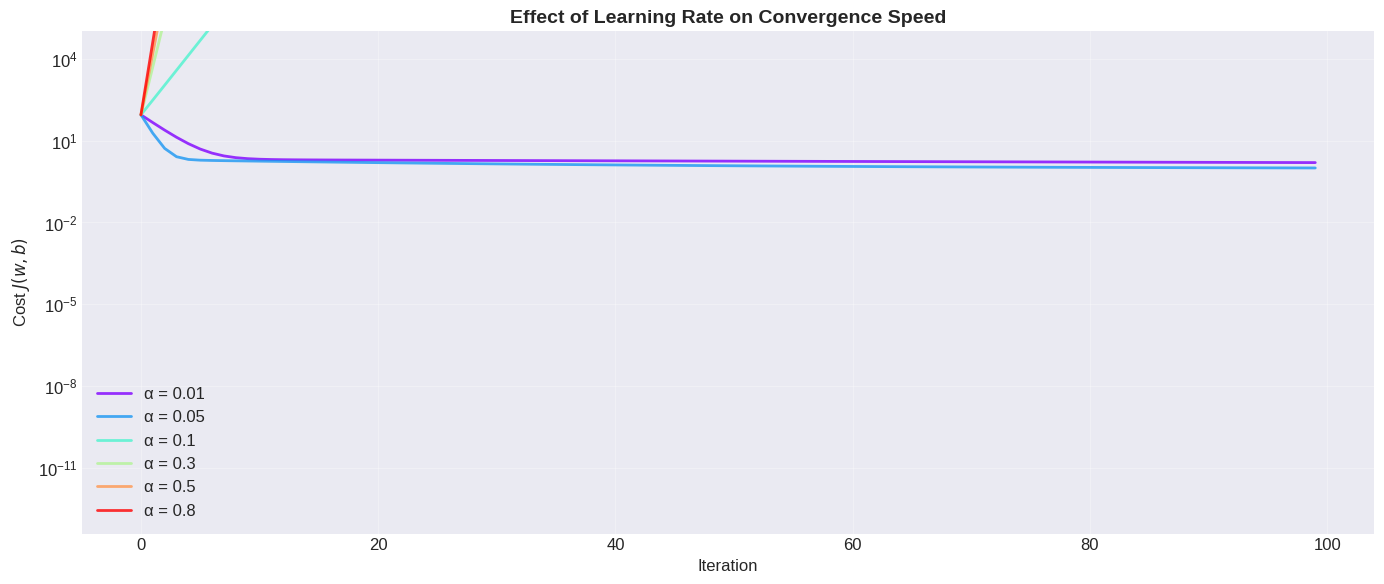

📈 Observations:
   • Very small α (0.01): Slow but steady convergence
   • Medium α (0.1-0.3): Fast, stable convergence
   • Large α (0.5+): May oscillate or diverge


In [34]:
# Compare multiple learning rates
learning_rates = [0.01, 0.05, 0.1, 0.3, 0.5, 0.8]
colors = plt.cm.rainbow(np.linspace(0, 1, len(learning_rates)))

plt.figure(figsize=(14, 6))

for idx, (lr, color) in enumerate(zip(learning_rates, colors)):
    model = LinearRegressionGD(learning_rate=lr, n_iterations=100)
    model.fit(X, y)

    # Filter out infinite or NaN loss values before plotting
    valid_loss_history = [loss for loss in model.loss_history if np.isfinite(loss)]

    if valid_loss_history: # Only plot if there are valid loss values
        # Fixed: Removed the extra $ signs causing the parse error
        plt.plot(range(len(valid_loss_history)), valid_loss_history,
                 color=color, linewidth=2, label=f'α = {lr}', alpha=0.8)
    else:
        print(f"Warning: No valid loss history to plot for alpha={lr}. Model diverged completely.")

plt.xlabel('Iteration', fontsize=12)
plt.ylabel('Cost $J(w,b)$', fontsize=12)
plt.title('Effect of Learning Rate on Convergence Speed', fontweight='bold', fontsize=14)
plt.grid(True, alpha=0.3)
plt.yscale('log')
plt.legend()
# Set a reasonable upper limit for the y-axis to prevent overflow issues with log scale
plt.ylim(top=1e5)
plt.tight_layout()
plt.show()

print("📈 Observations:")
# Fixed: Removed the extra $ signs in the print statements
print("   • Very small α (0.01): Slow but steady convergence")
print("   • Medium α (0.1-0.3): Fast, stable convergence")
print("   • Large α (0.5+): May oscillate or diverge")


## 7. Key Takeaways

1. **Gradient descent is walking downhill** - The algorithm iteratively moves parameters in the direction that reduces cost, just like finding the bottom of a valley by always walking downhill.

2. **Derivatives point the way** - The derivative tells us the slope at our current position. Positive derivative means "go left" (decrease parameter), negative means "go right" (increase parameter).

3. **Learning rate controls step size** - $\alpha$ is crucial: too small = painfully slow; too large = may overshoot and never reach the minimum.

4. **Simultaneous updates are essential** - Always update all parameters using their old values before assigning new values. This maintains the algorithm's mathematical properties.

5. **Linear regression's cost is convex** - Unlike some functions with multiple valleys, the squared error cost function is bowl-shaped with a single global minimum. Gradient descent always finds the best parameters.

6. **Batch gradient descent uses all data** - Each step considers every training example, giving stable gradient estimates at the cost of computation.

7. **Automatic step size adjustment** - As we approach the minimum, derivatives naturally become smaller, so steps automatically shrink—no need to manually decrease $\alpha$.

8. **Convergence is guaranteed** - With appropriate $\alpha$, gradient descent will converge to the global minimum for linear regression's convex cost function.

9. **The $\frac{1}{2}$ in cost function was intentional** - It cancels the $2$ from derivatives, giving cleaner update formulas.

10. **Foundation for deep learning** - The same gradient descent algorithm, with minor modifications, trains neural networks with millions of parameters.

## 8. Quick Revision

### Key Formulas

| Component | Formula |
|-----------|---------|
| **Model** | $f_{w,b}(x) = wx + b$ |
| **Cost Function** | $J(w,b) = \frac{1}{2m}\sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})^2$ |
| **Gradient w** | $\frac{\partial J}{\partial w} = \frac{1}{m}\sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)}) x^{(i)}$ |
| **Gradient b** | $\frac{\partial J}{\partial b} = \frac{1}{m}\sum_{i=1}^{m} (f_{w,b}(x^{(i)}) - y^{(i)})$ |
| **Update w** | $w = w - \alpha \frac{\partial J}{\partial w}$ |
| **Update b** | $b = b - \alpha \frac{\partial J}{\partial b}$ |

### Essential Definitions

| Term | Definition |
|------|------------|
| **Gradient Descent** | Iterative algorithm to minimize cost by following steepest descent |
| **Learning Rate ($\alpha$)** | Step size multiplier ($0 < \alpha \leq 1$ typically) |
| **Derivative** | Slope of function at a point; positive = uphill, negative = downhill |
| **Convergence** | Reaching minimum where parameters stop changing |
| **Batch** | Using ALL training examples per update |
| **Convex** | Bowl-shaped function with one global minimum |
| **Simultaneous Update** | Updating all parameters using their old values |

### Common Issues and Solutions

| Problem | Symptom | Solution |
|---------|---------|----------|
| **Learning rate too small** | Cost decreases extremely slowly | Increase $\alpha$ |
| **Learning rate too large** | Cost increases or oscillates | Decrease $\alpha$ |
| **Not enough iterations** | Parameters not yet converged | Run more iterations |
| **Bad initialization** | Starting far from minimum | Initialize to 0 (safe for convex) |

### Quick True/False Check

- ✅ Gradient descent always finds the global minimum for linear regression (True - because cost is convex)
- ❌ A larger learning rate always speeds up convergence (False - can cause divergence)
- ✅ The derivative tells us which direction is uphill (True - we go opposite direction)
- ❌ We should update $w$ first, then use new $w$ to update $b$ (False - must update simultaneously)
- ✅ Batch gradient descent uses all training examples each step (True)

---

**Congratulations!** You now understand gradient descent—the algorithm that powers machine learning from simple linear regression to deep neural networks. This foundation will serve you throughout your entire ML journey.